In [3]:
# Clinical Report Analyzer

# Developed by Payam Razavi

# Cedars-Sinai / Los Angeles Pierce College AI Initiative

# This notebook contains the Phase 1 machine learning pipeline
# for pathology report classification using TF-IDF and
# multiple machine learning models.
    
# ==========================================
# PHASE 1 — PROJECT SETUP AND DATA LOADING
# ==========================================

import os
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set working directory
os.chdir(r"D:\NLP personal project\Phase1_Model_Development")  # <-- change if needed

# Load dataset
df = pd.read_csv("tcga_reports_cancer_type.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (9523, 4)


In [3]:
# ==========================================
# DATA EXPLORATION AND CLASS DISTRIBUTION
# ==========================================

# Inspect dataset structure, preview sample rows,
# and examine the distribution of cancer types
# across the dataset

df.columns
df.head()
df["cancer_type_name"].value_counts()

cancer_type_name
Breast invasive carcinoma                                           1034
Uterine Corpus Endometrial Carcinoma                                 546
Kidney renal clear cell carcinoma                                    525
Head and Neck squamous cell carcinoma                                520
Lung adenocarcinoma                                                  488
Thyroid carcinoma                                                    487
Brain Lower Grade Glioma                                             469
Lung squamous cell carcinoma                                         468
Prostate adenocarcinoma                                              446
Colon adenocarcinoma                                                 418
Glioblastoma multiforme                                              399
Bladder Urothelial Carcinoma                                         379
Ovarian serous cystadenocarcinoma                                    371
Stomach adenocarcinoma            

In [4]:
# ==========================================
# DATASET VERIFICATION AND SAMPLE INSPECTION
# ==========================================

# Reload the dataset and inspect sample entries
# to verify data structure and cancer type labels

mapping = pd.read_csv("tcga_reports_cancer_type.csv")
mapping.head()

,patient_id,text,cancer_type,cancer_type_name
0,TCGA-BP-5195,Date of Recelpt: Clinical Diagnosis & History:...,KIRC,Kidney renal clear cell carcinoma
1,TCGA-D7-8573,"Material: 1) Material: stomach, Method of coll...",STAD,Stomach adenocarcinoma
2,TCGA-EI-7004,page 1 / 1. copy No. 3. Examination: Histopath...,READ,Rectum adenocarcinoma
3,TCGA-EB-A82B,Patient ID: Gross Description: A mass is locat...,SKCM,Skin Cutaneous Melanoma
4,TCGA-A6-3808,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,COAD,Colon adenocarcinoma


In [5]:
# ==========================================
# TEXT PREPROCESSING
# ==========================================

# Clean and normalize pathology report text
# by converting to lowercase and removing
# line breaks before feature extraction

def preprocess_text(text):
    text = text.lower()
    text = text.replace("\n", " ")
    return text

df["clean_text"] = df["text"].apply(preprocess_text)

In [6]:
# ==========================================
# TF-IDF FEATURE EXTRACTION
# ==========================================

# Convert clinical text into numerical features
# using TF-IDF vectorization.
#
# Custom stopwords are added to remove
# non-informative pathology report terms.
#
# The vectorizer uses:
# - up to 5000 features
# - unigrams and bigrams
# - minimum document frequency filtering

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

custom_stopwords = ENGLISH_STOP_WORDS.union([
    "left", "right", "upper", "lower", "pole", "section",
    "margin", "specimen", "clinical", "history", "diagnosis",
    "material", "patient", "id", "notes", "copy", "page",
    "cm", "partial"
])

vectorizer = TfidfVectorizer(
    stop_words=list(custom_stopwords),
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3
)

X = vectorizer.fit_transform(df["clean_text"])
y = df["cancer_type_name"]

In [7]:
# ==========================================
# TRAIN / TEST SPLIT
# ==========================================

# Split the dataset into training and testing sets.
#
# - 80% of the data is used for training
# - 20% is reserved for evaluation
#
# random_state is fixed for reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# ==========================================
# MACHINE LEARNING MODELS
# ==========================================

# Define the machine learning models used
# for cancer type classification.
#
# Models included:
# - Logistic Regression
# - Decision Tree
# - Random Forest

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

In [10]:
# ==========================================
# MODEL TRAINING AND EVALUATION
# ==========================================

# Train each machine learning model and evaluate
# performance on the test dataset.
#
# Evaluation metrics:
# - Accuracy
# - Precision
# - Recall
# - F1 Score
#
# Results are stored and converted into
# a comparison table for easier analysis

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }

# Convert results into a DataFrame
results_df = pd.DataFrame(results).T

# Round values for cleaner presentation
results_df = results_df.round(4)

# Sort models by F1 score (highest first)
results_df = results_df.sort_values(by="f1", ascending=False)

results_df

,accuracy,precision,recall,f1
Random Forest,0.9559,0.9598,0.9559,0.9516
Logistic Regression,0.9391,0.9378,0.9391,0.9308
Decision Tree,0.9255,0.9292,0.9255,0.9259


In [11]:
# ==========================================
# BEST MODEL SELECTION
# ==========================================

# Select the best-performing model based
# on the highest weighted F1 score

best_model_name = max(results, key=lambda x: results[x]["f1"])
best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


In [41]:
# ==========================================
# DETAILED CLASSIFICATION REPORT
# ==========================================

# Generate a detailed evaluation report
# for the best-performing model using
# the held-out test dataset.
#
# Metrics are calculated for each
# cancer class individually, including:
# - Precision
# - Recall
# - F1 Score
# - Support

from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

                                                                  precision    recall  f1-score   support

                                        Adrenocortical carcinoma       1.00      0.87      0.93        23
                                    Bladder Urothelial Carcinoma       0.99      1.00      0.99        84
                                        Brain Lower Grade Glioma       0.94      1.00      0.97        90
                                       Breast invasive carcinoma       0.99      1.00      1.00       204
Cervical squamous cell carcinoma and endocervical adenocarcinoma       1.00      0.92      0.96        51
                                              Cholangiocarcinoma       1.00      0.46      0.63        13
                                            Colon adenocarcinoma       0.85      0.99      0.91        96
                                            Esophageal carcinoma       0.94      0.97      0.95        32
                                         Glio

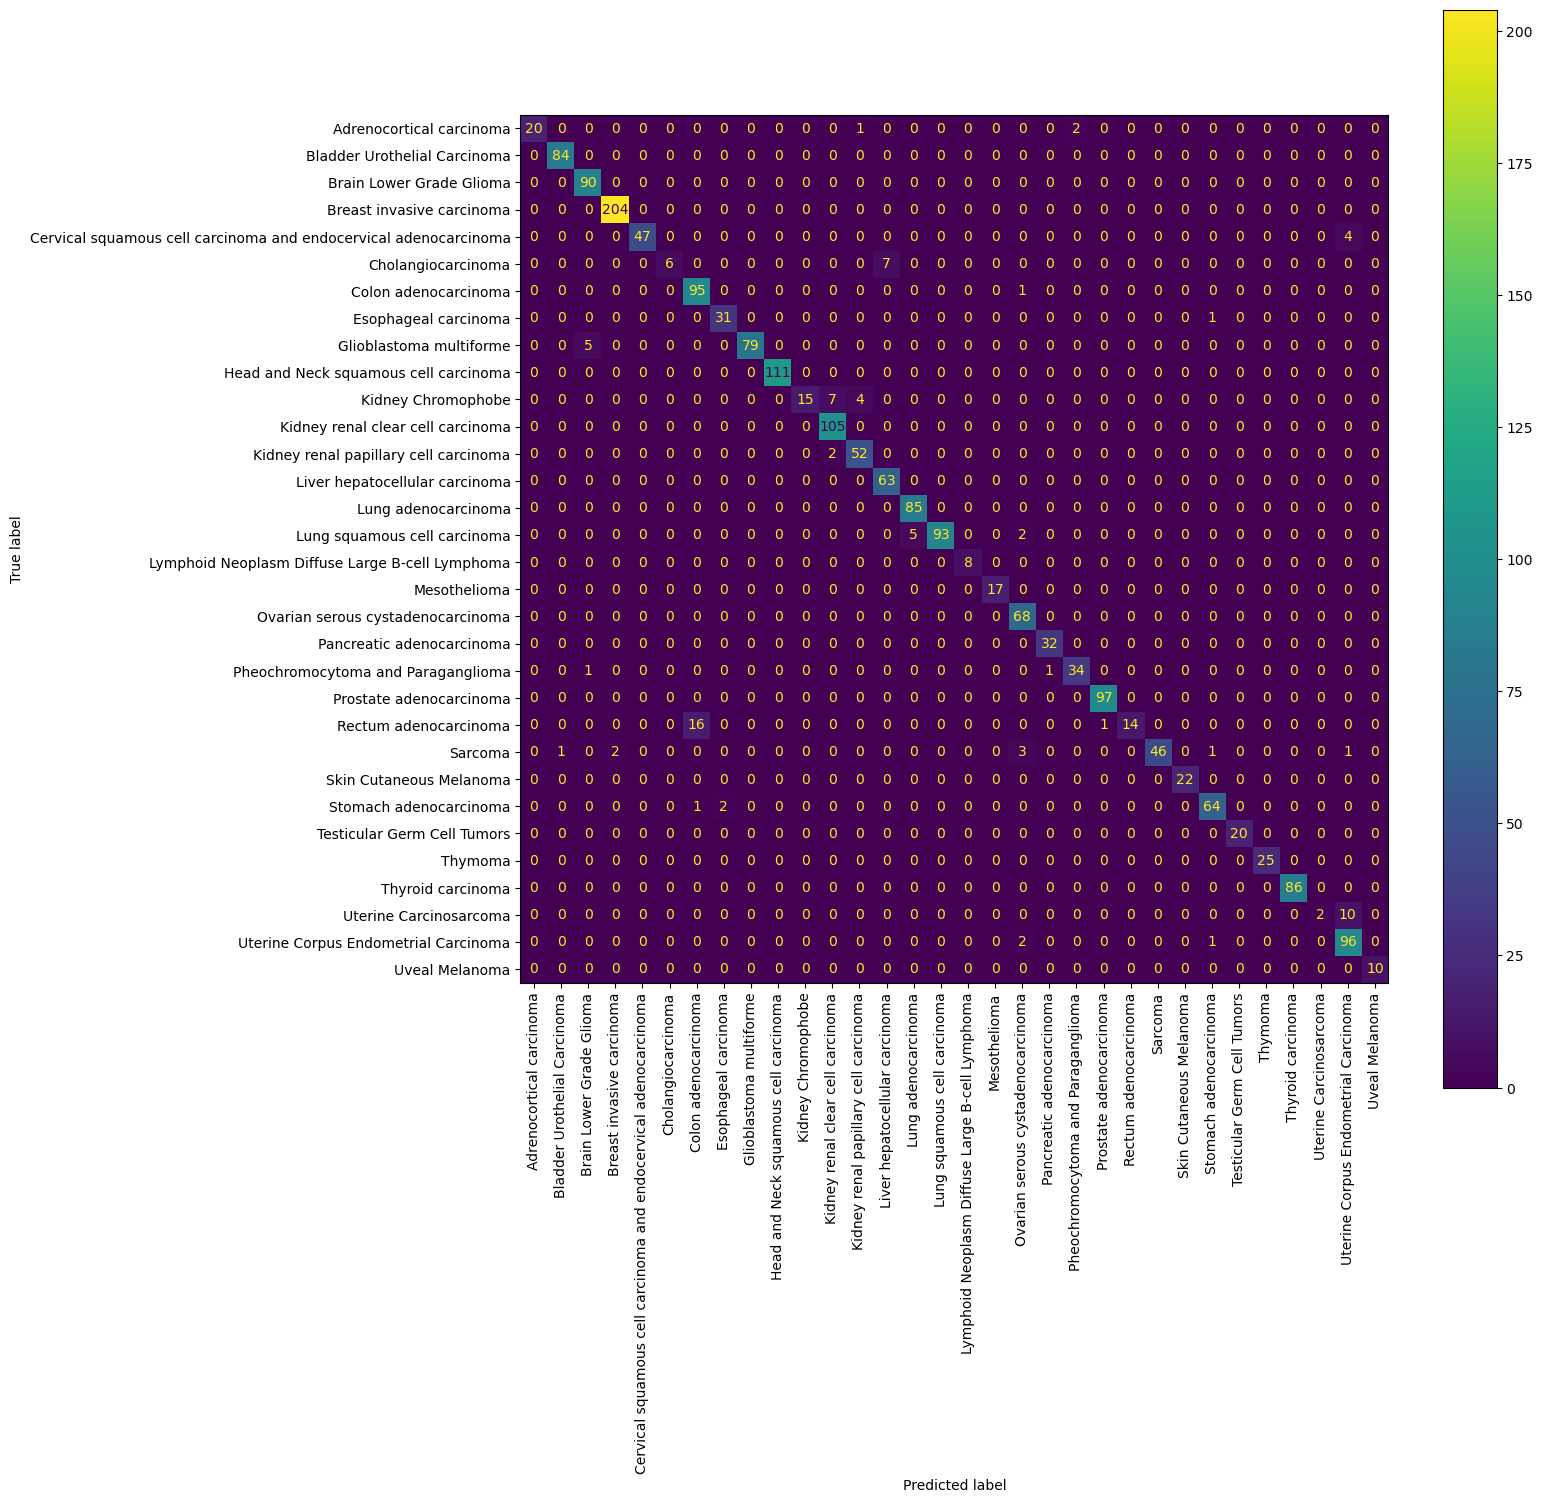

In [43]:
# ==========================================
# CONFUSION MATRIX VISUALIZATION
# ==========================================

# Visualize prediction performance of the
# best-performing model across cancer classes.
#
# The confusion matrix highlights:
# - correctly classified reports
# - misclassified cancer types
# - class-level prediction patterns

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 14))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90,
    ax=ax
)

plt.show()

In [12]:
# ==========================================
# SAVE TRAINED MODEL AND VECTORIZER
# ==========================================

# Save the best-performing trained model
# and TF-IDF vectorizer for later use
# in the report analysis application

import joblib

joblib.dump(best_model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

In [13]:
# =====================================================
# PHASE 2 — CLINICAL REPORT ANALYSIS (INFERENCE)
# =====================================================

# In this phase, the trained model and vectorizer
# are applied to new pathology reports.
#
# The same preprocessing used during training
# must also be applied to new incoming reports
# to maintain consistency between training
# and prediction.

# ==========================================
# REUSABLE TEXT PREPROCESSING FUNCTION
# ==========================================

# Define a reusable preprocessing function
# to normalize clinical report text before
# prediction and analysis

def preprocess_text(text):
    text = text.lower()
    text = text.replace("\n", " ")
    return text

In [49]:
# ==========================================
# LOAD TRAINED MODEL AND GENERATE PREDICTIONS
# ==========================================

# Load the trained machine learning model
# and TF-IDF vectorizer saved during Phase 1.
#
# Define a prediction function that:
# - preprocesses a new pathology report
# - converts text into TF-IDF features
# - generates prediction probabilities
# - returns the top predicted cancer types
#   with confidence scores

import joblib

loaded_model = joblib.load("model.pkl")
loaded_vectorizer = joblib.load("vectorizer.pkl")

def predict_report(report_text, top_k=3):
    clean_text = preprocess_text(report_text)
    text_vector = loaded_vectorizer.transform([clean_text])

    # Generate probability scores for each cancer class
    probs = loaded_model.predict_proba(text_vector)[0]
    
    top_indices = probs.argsort()[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        results.append((loaded_model.classes_[idx], probs[idx]))
    
    return results

In [23]:
# ==========================================
# SAMPLE PREDICTION VALIDATION
# ==========================================

# Select a sample pathology report and compare
# the model's top prediction against the
# actual cancer type label.
#
# This provides a simple validation example
# for the trained inference pipeline.

sample_report = df["text"].iloc[0]
actual_label = df["cancer_type_name"].iloc[0]

results = predict_report(sample_report)

print("Actual cancer type:", actual_label)
print("\nTop predictions:")

for label, prob in results:
    print(label, "→", round(prob, 3))

top_prediction = results[0][0]

print("\nTop prediction matches actual?",
      top_prediction == actual_label)

Actual cancer type: Kidney renal clear cell carcinoma

Top predictions:
Kidney renal clear cell carcinoma → 1.0
Uveal Melanoma → 0.0
Uterine Corpus Endometrial Carcinoma → 0.0

Top prediction matches actual? True


In [19]:
# ==========================================
# KEYWORD EXTRACTION
# ==========================================

# Extract the most important TF-IDF keywords
# from a pathology report.
#
# These keywords help identify clinically
# relevant terms contributing to the model's
# understanding of the report content.

def extract_top_keywords(report_text, vectorizer, top_k=10):
    clean_text = preprocess_text(report_text)
    text_vector = vectorizer.transform([clean_text])

    feature_names = vectorizer.get_feature_names_out()
    scores = text_vector.toarray()[0]

    top_indices = scores.argsort()[-top_k:][::-1]

    keywords = []
    for idx in top_indices:
        if scores[idx] > 0:
            keywords.append((feature_names[idx], scores[idx]))

    return keywords

In [25]:
# ==========================================
# SAMPLE KEYWORD EXTRACTION
# ==========================================

# Extract the highest-scoring TF-IDF keywords
# from a sample pathology report to identify
# clinically important terms within the text.

sample_report = df["text"].iloc[0]

keywords = extract_top_keywords(sample_report, loaded_vectorizer, top_k=10)

for word, score in keywords:
    print(word, "→", round(score, 4))

renal → 0.3922
kidney → 0.2639
kidney nephrectomy → 0.1743
tumor → 0.1508
renal tumor → 0.145
nephrectomy → 0.1372
renal cortical → 0.1332
perirenal → 0.1212
rs → 0.1194
fsc → 0.1142


In [27]:
# ==========================================
# KEYWORD LIST EXTRACTION
# ==========================================

# Convert extracted keyword-score pairs into
# a simplified keyword list for downstream
# analysis and sentence highlighting.

def extract_top_keyword_list(report_text, vectorizer, top_k=10):
    keywords = extract_top_keywords(report_text, vectorizer, top_k=top_k)
    return [word for word, score in keywords]

In [28]:
# ==========================================
# SIMPLIFIED KEYWORD LIST
# ==========================================

# Generate a simplified list of extracted
# keywords without TF-IDF scores.
#
# This format is useful for downstream
# tasks such as sentence highlighting
# and keyword matching.

extract_top_keyword_list(sample_report, loaded_vectorizer, top_k=10)

['renal',
 'kidney',
 'kidney nephrectomy',
 'tumor',
 'renal tumor',
 'nephrectomy',
 'renal cortical',
 'perirenal',
 'rs',
 'fsc']

In [32]:
# ==========================================
# SENTENCE HIGHLIGHTING AND EXPLAINABILITY
# ==========================================

# Split pathology reports into sentences and
# identify the most clinically relevant
# sentences based on extracted TF-IDF keywords.
#
# Sentences are scored according to keyword
# matches to help explain why the model
# generated its predictions.

import re

def split_into_sentences(text):
    sentences = re.split(r'(?<=[.!?])\s+|\n+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return sentences

def highlight_top_sentences(
    report_text,
    vectorizer,
    top_k_keywords=10,
    top_k_sentences=3
):
    keywords = extract_top_keyword_list(
        report_text,
        vectorizer,
        top_k=top_k_keywords
    )

    sentences = split_into_sentences(report_text)

    scored_sentences = []

    for sentence in sentences:
        sentence_lower = sentence.lower()
        score = 0
        matched_keywords = []

        for kw in keywords:
            if kw in sentence_lower:
                score += 1
                matched_keywords.append(kw)

        if score > 0:
            scored_sentences.append({
                "sentence": sentence,
                "score": score,
                "matched_keywords": matched_keywords
            })

    scored_sentences = sorted(
        scored_sentences,
        key=lambda x: x["score"],
        reverse=True
    )

    return scored_sentences[:top_k_sentences]

In [33]:
# ==========================================
# SAMPLE SENTENCE HIGHLIGHTING
# ==========================================

# Identify and display the most relevant
# diagnostic sentences from a sample
# pathology report.
#
# Sentences are ranked according to the
# number of matched clinical keywords.

highlighted = highlight_top_sentences(
    sample_report,
    loaded_vectorizer,
    top_k_keywords=10,
    top_k_sentences=3
)

for i, item in enumerate(highlighted, 1):
    print(f"Sentence {i}:")
    print(item["sentence"])
    print("Score:", item["score"])
    print("Matched keywords:", item["matched_keywords"])
    print()

Sentence 1:
Kidney, Left Upper Pole; Partial Nephrectomy: Tumor Type: Renal cell carcinoma - Conventional (clear cell) type.
Score: 4
Matched keywords: ['renal', 'kidney', 'tumor', 'nephrectomy']

Sentence 2:
Staging for renal cell carcinoma/oncocytoma: pT1 Tumor <= 7.0 cm in greatest dimension limited to the kidney.
Score: 3
Matched keywords: ['renal', 'kidney', 'tumor']

Sentence 3:
The specimen Is received fresh for frozen section consultation, labeled "left upper pole renal tumor stitch marks deep margin".
Score: 3
Matched keywords: ['renal', 'tumor', 'renal tumor']



In [34]:
# ==========================================
# COMPLETE NLP REPORT ANALYSIS PIPELINE
# ==========================================

# Integrate prediction, keyword extraction,
# and sentence highlighting into a unified
# clinical report analysis pipeline.
#
# The system:
# - predicts cancer types
# - returns confidence scores
# - extracts important keywords
# - highlights clinically relevant sentences

def analyze_report(
    report_text,
    top_k_predictions=3,
    top_k_keywords=10,
    top_k_sentences=3
):
    clean_text = preprocess_text(report_text)
    text_vector = loaded_vectorizer.transform([clean_text])

    probs = loaded_model.predict_proba(text_vector)[0]
    top_indices = probs.argsort()[-top_k_predictions:][::-1]

    predictions = []

    for idx in top_indices:
        predictions.append({
            "cancer_type": loaded_model.classes_[idx],
            "probability": float(probs[idx])
        })

    keywords = extract_top_keywords(
        report_text,
        loaded_vectorizer,
        top_k=top_k_keywords
    )

    keywords = [
        {"word": word, "score": float(score)}
        for word, score in keywords
    ]

    highlighted_sentences = highlight_top_sentences(
        report_text,
        loaded_vectorizer,
        top_k_keywords=top_k_keywords,
        top_k_sentences=top_k_sentences
    )

    return {
        "predictions": predictions,
        "keywords": keywords,
        "highlighted_sentences": highlighted_sentences
    }

In [35]:
# ==========================================
# COMPLETE SAMPLE REPORT ANALYSIS
# ==========================================

# Run the full NLP clinical report analysis
# pipeline on a sample pathology report.
#
# The system:
# - predicts cancer types
# - returns confidence scores
# - extracts important keywords
# - highlights clinically relevant sentences

result = analyze_report(sample_report)

print("Top predictions:")
for item in result["predictions"]:
    print(item["cancer_type"], "→", round(item["probability"], 3))

print("\nTop keywords:")
for item in result["keywords"]:
    print(item["word"], "→", round(item["score"], 4))

print("\nHighlighted sentences:")
for item in result["highlighted_sentences"]:
    print("-", item["sentence"])
    print("  score:", item["score"])
    print("  matched:", item["matched_keywords"])

Top predictions:
Kidney renal clear cell carcinoma → 1.0
Uveal Melanoma → 0.0
Uterine Corpus Endometrial Carcinoma → 0.0

Top keywords:
renal → 0.3922
kidney → 0.2639
kidney nephrectomy → 0.1743
tumor → 0.1508
renal tumor → 0.145
nephrectomy → 0.1372
renal cortical → 0.1332
perirenal → 0.1212
rs → 0.1194
fsc → 0.1142

Highlighted sentences:
- Kidney, Left Upper Pole; Partial Nephrectomy: Tumor Type: Renal cell carcinoma - Conventional (clear cell) type.
  score: 4
  matched: ['renal', 'kidney', 'tumor', 'nephrectomy']
- Staging for renal cell carcinoma/oncocytoma: pT1 Tumor <= 7.0 cm in greatest dimension limited to the kidney.
  score: 3
  matched: ['renal', 'kidney', 'tumor']
- The specimen Is received fresh for frozen section consultation, labeled "left upper pole renal tumor stitch marks deep margin".
  score: 3
  matched: ['renal', 'tumor', 'renal tumor']


In [36]:
# ==========================================
# MULTI-SAMPLE REPORT VALIDATION
# ==========================================

# Run the complete NLP analysis pipeline
# on multiple pathology reports to evaluate
# prediction consistency across different
# clinical samples.

for i in [0, 10, 50, 100, 250]:

    sample_report = df["text"].iloc[i]
    actual_label = df["cancer_type_name"].iloc[i]

    result = analyze_report(sample_report)

    print("=" * 80)
    print("Index:", i)
    print("Actual:", actual_label)
    print("Top prediction:", result["predictions"][0]["cancer_type"])
    print("Confidence:", round(result["predictions"][0]["probability"], 3))

Index: 0
Actual: Kidney renal clear cell carcinoma
Top prediction: Kidney renal clear cell carcinoma
Confidence: 1.0
Index: 10
Actual: Head and Neck squamous cell carcinoma
Top prediction: Head and Neck squamous cell carcinoma
Confidence: 0.93
Index: 50
Actual: Brain Lower Grade Glioma
Top prediction: Brain Lower Grade Glioma
Confidence: 0.69
Index: 100
Actual: Uterine Carcinosarcoma
Top prediction: Uterine Carcinosarcoma
Confidence: 0.84
Index: 250
Actual: Esophageal carcinoma
Top prediction: Esophageal carcinoma
Confidence: 0.99


In [37]:
# ==========================================
# MODEL ERROR ANALYSIS
# ==========================================

# Run the NLP inference pipeline across the
# dataset and identify reports where the
# predicted cancer type does not match
# the actual label.
#
# Misclassified cases are stored for
# further inspection and analysis.

mistakes = []

for i in range(len(df)):

    sample_report = df["text"].iloc[i]
    actual_label = df["cancer_type_name"].iloc[i]

    result = analyze_report(sample_report)

    predicted = result["predictions"][0]["cancer_type"]

    if predicted != actual_label:
        mistakes.append((
            i,
            actual_label,
            predicted,
            result["predictions"][0]["probability"]
        ))

len(mistakes)

89

In [39]:
# ==========================================
# SAMPLE MISCLASSIFIED REPORTS
# ==========================================

# Display example misclassified reports
# identified during inference error analysis.
#
# Each entry contains:
# - dataset index
# - actual cancer type
# - predicted cancer type
# - prediction confidence score

mistakes[:10]

[(30, 'Rectum adenocarcinoma', 'Colon adenocarcinoma', 0.51),
 (111, 'Rectum adenocarcinoma', 'Colon adenocarcinoma', 0.45),
 (185, 'Uterine Carcinosarcoma', 'Uterine Corpus Endometrial Carcinoma', 0.54),
 (245, 'Rectum adenocarcinoma', 'Colon adenocarcinoma', 0.47),
 (510, 'Stomach adenocarcinoma', 'Colon adenocarcinoma', 0.31),
 (603, 'Sarcoma', 'Bladder Urothelial Carcinoma', 0.37),
 (745, 'Cholangiocarcinoma', 'Liver hepatocellular carcinoma', 0.2),
 (765, 'Uterine Carcinosarcoma', 'Uterine Corpus Endometrial Carcinoma', 0.44),
 (970, 'Lung squamous cell carcinoma', 'Lung adenocarcinoma', 0.51),
 (1095, 'Rectum adenocarcinoma', 'Colon adenocarcinoma', 0.5)]

In [40]:
# ==========================================
# DETAILED MISCLASSIFICATION ANALYSIS
# ==========================================

# Select a misclassified pathology report
# and inspect the complete NLP analysis
# pipeline output.
#
# This includes:
# - actual vs predicted cancer type
# - confidence scores
# - extracted keywords
# - highlighted diagnostic sentences

i, actual, predicted, conf = mistakes[0]

sample_report = df["text"].iloc[i]

result = analyze_report(sample_report)

print("Actual:", actual)
print("Predicted:", predicted)
print("Confidence:", round(conf, 3))

print("\nTop predictions:")
for item in result["predictions"]:
    print(item["cancer_type"], "->", round(item["probability"], 3))

print("\nTop keywords:")
for item in result["keywords"]:
    print(item["word"], "->", round(item["score"], 4))

print("\nHighlighted sentences:")
for item in result["highlighted_sentences"]:
    print("-", item["sentence"])
    print(" score:", item["score"])
    print(" matched:", item["matched_keywords"])
    print()

Actual: Rectum adenocarcinoma
Predicted: Colon adenocarcinoma
Confidence: 0.51

Top predictions:
Colon adenocarcinoma -> 0.51
Rectum adenocarcinoma -> 0.41
Stomach adenocarcinoma -> 0.03

Top keywords:
34 -> 0.3559
pt3 -> 0.2452
fatty tissue -> 0.2406
fatty -> 0.2074
diagnosed -> 0.1915
aboral -> 0.188
conclusion -> 0.1839
rectum -> 0.1814
pericolic -> 0.1801
prepared -> 0.1786

Highlighted sentences:
- in the distal rectum, with superficial infiltration of the perirectal fatty tissue (pT3) and.
 score: 4
 matched: ['pt3', 'fatty tissue', 'fatty', 'rectum']

- Follow-up report: Following acetone clarification, 34 lymph nodes in the pericolic fatty tissue bordering the.
 score: 4
 matched: ['34', 'fatty tissue', 'fatty', 'pericolic']

- In conclusion and in summary a stage of pT3 pN1 (3/34) is established.
 score: 3
 matched: ['34', 'pt3', 'conclusion']



In [44]:
# ==========================================
# CONFIDENCE SCORE ANALYSIS
# ==========================================

# Compare model confidence scores between
# correct and incorrect predictions across
# the dataset.
#
# This helps evaluate whether prediction
# confidence correlates with model accuracy.

correct_confidences = []
wrong_confidences = []

for i in range(len(df)):

    sample_report = df["text"].iloc[i]
    actual_label = df["cancer_type_name"].iloc[i]

    result = analyze_report(sample_report)

    top_pred = result["predictions"][0]["cancer_type"]
    top_prob = result["predictions"][0]["probability"]

    if top_pred == actual_label:
        correct_confidences.append(top_prob)
    else:
        wrong_confidences.append(top_prob)

print(
    "Average confidence (correct):",
    sum(correct_confidences) / len(correct_confidences)
)

print(
    "Average confidence (wrong):",
    sum(wrong_confidences) / len(wrong_confidences)
)

Average confidence (correct): 0.8913063659628478
Average confidence (wrong): 0.4523377109781604


In [46]:
# ==========================================
# EXTERNAL CLINICAL REPORT ANALYSIS
# ==========================================

# Test the NLP pipeline on an external
# pathology report that was not directly
# selected from the training dataset.
#
# This demonstrates how the system can
# analyze new clinical reports in a
# real-world inference scenario.

external_report = """
UTERUS, MYOMECTOMY – LEIOMYOSARCOMA (8.5 CM) WITH MARGINAL INVOLVEMENT.
Histologic Type: Leiomyosarcoma.
Uterine mass. Tumor size 8.5 cm. Lymph-vascular invasion present.
"""

result = analyze_report(external_report)

print("Top predictions:")
for item in result["predictions"]:
    print(item["cancer_type"], "→", round(item["probability"], 3))

print("\nTop keywords:")
for item in result["keywords"]:
    print(item["word"], "→", round(item["score"], 4))

print("\nHighlighted sentences:")
for item in result["highlighted_sentences"]:
    print("-", item["sentence"])

Top predictions:
Uterine Corpus Endometrial Carcinoma → 0.15
Testicular Germ Cell Tumors → 0.11
Sarcoma → 0.11

Top keywords:
leiomyosarcoma → 0.7181
mass tumor → 0.3442
lymph vascular → 0.2348
uterine → 0.2155
uterus → 0.202
invasion present → 0.1722
vascular invasion → 0.17
involvement → 0.1698
histologic type → 0.1416
vascular → 0.1384

Highlighted sentences:
- UTERUS, MYOMECTOMY – LEIOMYOSARCOMA (8.5 CM) WITH MARGINAL INVOLVEMENT.
- Lymph-vascular invasion present.
- Histologic Type: Leiomyosarcoma.


In [47]:
# ==========================================
# FULL REPORT HTML HIGHLIGHTING
# ==========================================

# Convert the full pathology report into
# HTML and visually highlight the selected
# important sentences in yellow.
#
# This function is useful for the Streamlit
# app because it allows the user to see
# relevant diagnostic sentences inside the
# original report text.

import html
import re

def highlight_sentences_in_report(report_text, highlighted_sentences):
    """
    Return the full report as HTML with highlighted sentences marked in yellow.
    """

    # Escape HTML first so raw report text is safe to display
    escaped_report = html.escape(report_text)

    # Sort longest first so longer matches are replaced before shorter ones
    sorted_sentences = sorted(
        highlighted_sentences,
        key=lambda x: len(x["sentence"]),
        reverse=True
    )

    highlighted_html = escaped_report

    for item in sorted_sentences:
        sentence = item["sentence"].strip()

        if not sentence:
            continue

        escaped_sentence = html.escape(sentence)

        replacement = (
            f'<mark style="background-color: #fff59d; padding: 2px 4px; '
            f'border-radius: 4px;">{escaped_sentence}</mark>'
        )

        # Replace exact sentence text with highlighted HTML
        highlighted_html = highlighted_html.replace(
            escaped_sentence,
            replacement
        )

    # Preserve line breaks in HTML output
    highlighted_html = highlighted_html.replace("\n", "<br>")

    return highlighted_html

In [48]:
# ==========================================
# FULL REPORT VISUAL HIGHLIGHTING DEMO
# ==========================================

# Generate HTML output for the complete
# pathology report with highlighted
# clinically relevant sentences.
#
# This output is used in the Streamlit
# interface to visually display important
# diagnostic information inside the
# original report text.

result = analyze_report(sample_report)

highlighted_report_html = highlight_sentences_in_report(
    sample_report,
    result["highlighted_sentences"]
)

highlighted_report_html[:2000]

'Diagnosis/Diagnoses: 1.: Excision specimen from peritoneum with angiectasia and subserosal fibrosis. <mark style="background-color: #fff59d; padding: 2px 4px; border-radius: 4px;">2.: Colonic resection specimen (evidently sigmoid) with an ulcerated carcinoma of the colon of.</mark> <mark style="background-color: #fff59d; padding: 2px 4px; border-radius: 4px;">the histological type of a moderately differentiated colorectal adenocarcinoma, measuring 2 cm.</mark> in its largest diameter and extending to a maximum of 8 cm from the resection margin. Invasive. tumor spread to the level of the muscularis propria. <mark style="background-color: #fff59d; padding: 2px 4px; border-radius: 4px;">Oral and aboral resection margin tumor-free.</mark> Twenty-six mesocolic lymph nodes tumor-free and with uncharacteristically reactive changes. Tumor stage therefore pT2 pNO (0/26) LO V0; G2 R0.'